In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'CPU':       'tab:blue',
    'Naive':     'tab:orange',
    'Optimized': 'tab:green',
    'P2':        'tab:green',
    'P3':        'tab:red',
    'Thrust':    'tab:purple',
}

MARKERS = {
    'CPU':       'o',
    'Naive':     '^',
    'Optimized': '*',
    'P2':        '*',
    'P3':        'p',
    'Thrust':    'D',
}

# Phase 2: Shared Memory Optimization

Evaluates the speedup from replacing global-memory accesses with shared memory tiles in the counting and scatter kernels.  
**Implementations compared:** CPU Sequential · GPU Naive · GPU Shared Memory (Opt) · GPU Thrust

In [2]:
df2 = pd.read_csv('phase2_averaged_results.csv')

df2['Throughput_Naive']  = (df2['Size'] / (df2['GPU_Naive_ms'] / 1000.0)) / 1e6
df2['Throughput_Opt']    = (df2['Size'] / (df2['GPU_Opt_ms']   / 1000.0)) / 1e6
df2['Throughput_Thrust'] = (df2['Size'] / (df2['GPU_Lib_ms']   / 1000.0)) / 1e6
df2['Opt_vs_Naive_Speedup'] = df2['GPU_Naive_ms'] / df2['GPU_Opt_ms']

print(f"Phase 2 — {len(df2)} data points")
print(f"Max speedup (Opt vs Naive): {df2['Opt_vs_Naive_Speedup'].max():.2f}x")

Phase 2 — 16 data points
Max speedup (Opt vs Naive): 13.76x


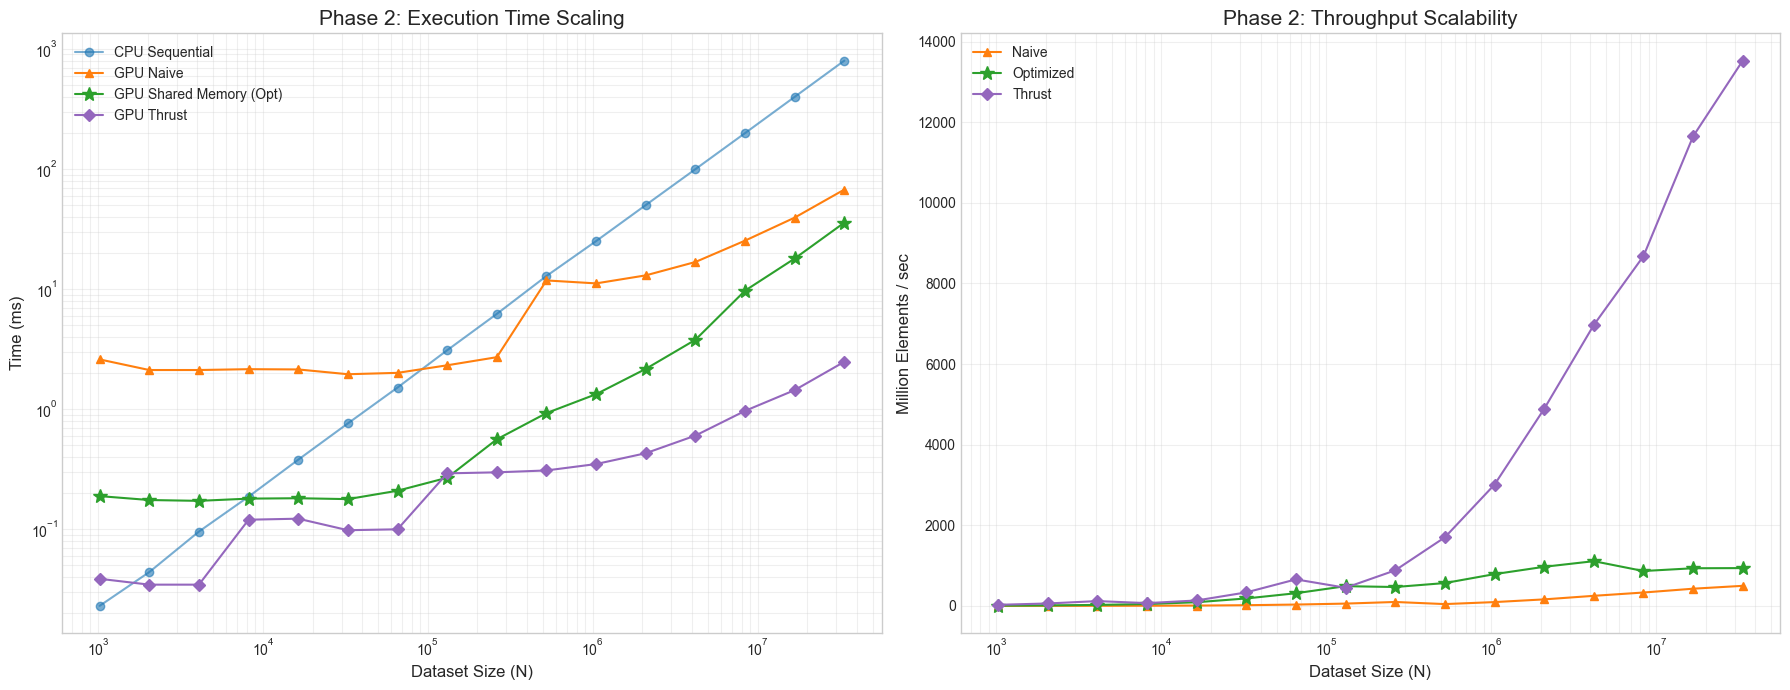

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.loglog(df2['Size'], df2['CPU_ms'],       label='CPU Sequential',          color=COLORS['CPU'],       marker=MARKERS['CPU'],       alpha=0.6)
ax1.loglog(df2['Size'], df2['GPU_Naive_ms'], label='GPU Naive',                color=COLORS['Naive'],     marker=MARKERS['Naive'])
ax1.loglog(df2['Size'], df2['GPU_Opt_ms'],   label='GPU Shared Memory (Opt)',  color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)
ax1.loglog(df2['Size'], df2['GPU_Lib_ms'],   label='GPU Thrust',               color=COLORS['Thrust'],    marker=MARKERS['Thrust'])
ax1.set_title('Phase 2: Execution Time Scaling', fontsize=15)
ax1.set_xlabel('Dataset Size (N)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

ax2.semilogx(df2['Size'], df2['Throughput_Naive'],  label='Naive',     color=COLORS['Naive'],     marker=MARKERS['Naive'])
ax2.semilogx(df2['Size'], df2['Throughput_Opt'],    label='Optimized', color=COLORS['Optimized'], marker=MARKERS['Optimized'], markersize=10)
ax2.semilogx(df2['Size'], df2['Throughput_Thrust'], label='Thrust',    color=COLORS['Thrust'],    marker=MARKERS['Thrust'])
ax2.set_title('Phase 2: Throughput Scalability', fontsize=15)
ax2.set_xlabel('Dataset Size (N)', fontsize=12)
ax2.set_ylabel('Million Elements / sec', fontsize=12)
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Phase 3: Memory Coalescing Optimization

Evaluates the additional gain from enforcing coalesced global-memory access patterns on top of the Phase 2 shared memory kernel.  
**Implementations compared:** CPU Sequential · GPU Naive · GPU Coalesced Memory (Opt) · GPU Thrust

In [4]:
df3 = pd.read_csv('phase3_averaged_results.csv')

df3['Throughput_Naive']  = (df3['Size'] / (df3['GPU_Naive_ms'] / 1000.0)) / 1e6
df3['Throughput_Opt']    = (df3['Size'] / (df3['GPU_Opt_ms']   / 1000.0)) / 1e6
df3['Throughput_Thrust'] = (df3['Size'] / (df3['GPU_Lib_ms']   / 1000.0)) / 1e6
df3['Opt_vs_Naive_Speedup'] = df3['GPU_Naive_ms'] / df3['GPU_Opt_ms']

print(f"Phase 3 — {len(df3)} data points")
print(f"Max speedup (Opt vs Naive): {df3['Opt_vs_Naive_Speedup'].max():.2f}x")

Phase 3 — 16 data points
Max speedup (Opt vs Naive): 12.45x


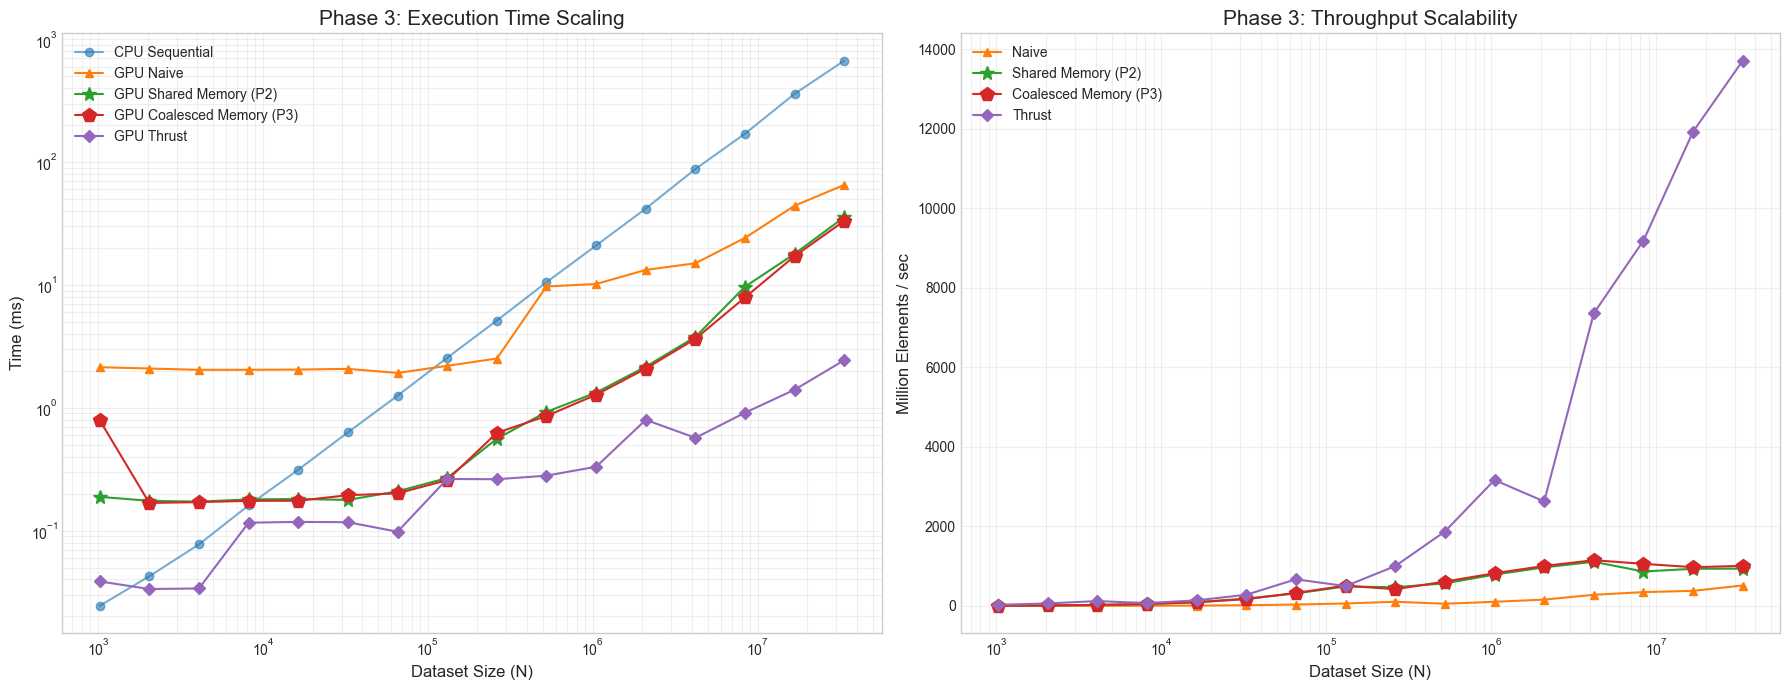

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Execution time (left)
ax1.loglog(df3['Size'], df3['CPU_ms'],       label='CPU Sequential',             color=COLORS['CPU'],       marker=MARKERS['CPU'],       alpha=0.6)
ax1.loglog(df3['Size'], df3['GPU_Naive_ms'], label='GPU Naive',                   color=COLORS['Naive'],     marker=MARKERS['Naive'])
ax1.loglog(df2['Size'], df2['GPU_Opt_ms'],   label='GPU Shared Memory (P2)',      color=COLORS['P2'],        marker=MARKERS['P2'],        markersize=10)
ax1.loglog(df3['Size'], df3['GPU_Opt_ms'],   label='GPU Coalesced Memory (P3)',   color=COLORS['P3'],        marker=MARKERS['P3'],        markersize=10)
ax1.loglog(df3['Size'], df3['GPU_Lib_ms'],   label='GPU Thrust',                  color=COLORS['Thrust'],    marker=MARKERS['Thrust'])
ax1.set_title('Phase 3: Execution Time Scaling', fontsize=15)
ax1.set_xlabel('Dataset Size (N)', fontsize=12)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

# Throughput (right)
ax2.semilogx(df3['Size'], df3['Throughput_Naive'],  label='Naive',                   color=COLORS['Naive'],  marker=MARKERS['Naive'])
ax2.semilogx(df2['Size'], df2['Throughput_Opt'],    label='Shared Memory (P2)',       color=COLORS['P2'],     marker=MARKERS['P2'],     markersize=10)
ax2.semilogx(df3['Size'], df3['Throughput_Opt'],    label='Coalesced Memory (P3)',    color=COLORS['P3'],     marker=MARKERS['P3'],     markersize=10)
ax2.semilogx(df3['Size'], df3['Throughput_Thrust'], label='Thrust',                   color=COLORS['Thrust'], marker=MARKERS['Thrust'])
ax2.set_title('Phase 3: Throughput Scalability', fontsize=15)
ax2.set_xlabel('Dataset Size (N)', fontsize=12)
ax2.set_ylabel('Million Elements / sec', fontsize=12)
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Phase 4: Consolidated Results

Cross-phase comparison of all four implementations with hardware-roofline analysis.  
**Implementations compared:** CPU Sequential · GPU Naive (P1) · GPU Shared (P2) · GPU Coalesced (P3) · GPU Thrust

---

### Plots
| Cell | What it shows |
|---|---|
| Speedup | Log-log speedup factor vs CPU across dataset sizes |
| Bandwidth | Effective memory bandwidth at peak load vs hardware ceiling |
| Roofline | Arithmetic intensity vs achieved performance on the roofline model |
| Throughput | Million elements/sec across dataset sizes |
| Execution time | Log-log scaling of raw execution time |
| Peak load bar | Absolute ms at maximum N for direct comparison |
| Summary dashboard | Three-panel overview (speedup · bandwidth · roofline) |

In [6]:
df4 = pd.read_csv('phase4_results.csv')

PEAK_BANDWIDTH_GBPS = 1555.0
PEAK_COMPUTE_GOPS   = 19500.0

df4['Speedup_Naive']  = df4['CPU_ms'] / df4['GPU_Naive_ms']
df4['Speedup_P2']     = df4['CPU_ms'] / df4['GPU_P2_Opt_ms']
df4['Speedup_P3']     = df4['CPU_ms'] / df4['GPU_P3_Opt_ms']
df4['Speedup_Thrust'] = df4['CPU_ms'] / df4['GPU_Thrust_ms']

df4['Thru_Naive']  = (df4['Size'] / (df4['GPU_Naive_ms']  / 1000.0)) / 1e6
df4['Thru_P2']     = (df4['Size'] / (df4['GPU_P2_Opt_ms'] / 1000.0)) / 1e6
df4['Thru_P3']     = (df4['Size'] / (df4['GPU_P3_Opt_ms'] / 1000.0)) / 1e6
df4['Thru_Thrust'] = (df4['Size'] / (df4['GPU_Thrust_ms'] / 1000.0)) / 1e6

BYTES_PER_ELEMENT    = 32
ARITHMETIC_INTENSITY = 10.0 / BYTES_PER_ELEMENT

N_max   = df4['Size'].max()
row_max = df4[df4['Size'] == N_max].iloc[0]

def calc_bw(time_ms):
    return (N_max * BYTES_PER_ELEMENT / (time_ms / 1000.0)) / 1e9

bw_naive  = calc_bw(row_max['GPU_Naive_ms'])
bw_p2     = calc_bw(row_max['GPU_P2_Opt_ms'])
bw_p3     = calc_bw(row_max['GPU_P3_Opt_ms'])
bw_thrust = calc_bw(row_max['GPU_Thrust_ms'])

gops_naive  = (N_max * 10 / (row_max['GPU_Naive_ms']  / 1000.0)) / 1e9
gops_p2     = (N_max * 10 / (row_max['GPU_P2_Opt_ms'] / 1000.0)) / 1e9
gops_p3     = (N_max * 10 / (row_max['GPU_P3_Opt_ms'] / 1000.0)) / 1e9
gops_thrust = (N_max * 10 / (row_max['GPU_Thrust_ms'] / 1000.0)) / 1e9

print(f"Phase 4 — {len(df4)} data points, N_max = {N_max:,}")

Phase 4 — 16 data points, N_max = 33,554,432


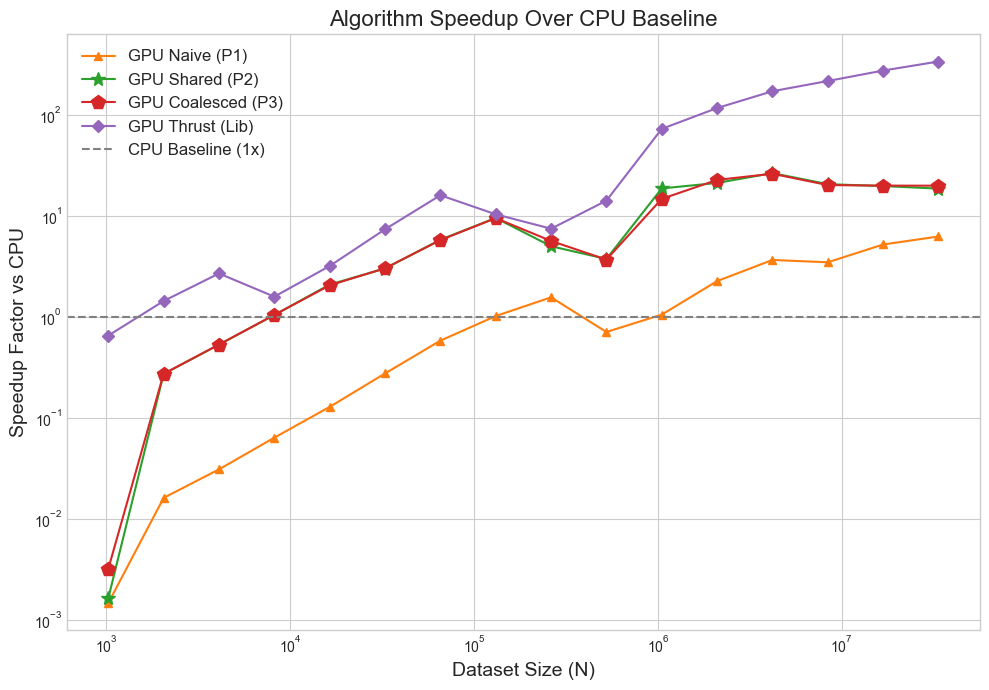

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df4['Size'], df4['Speedup_Naive'],  marker='^',                  label='GPU Naive (P1)',    color=COLORS['Naive'])
ax.plot(df4['Size'], df4['Speedup_P2'],     marker='*', markersize=10,   label='GPU Shared (P2)',   color=COLORS['P2'])
ax.plot(df4['Size'], df4['Speedup_P3'],     marker='p', markersize=10,   label='GPU Coalesced (P3)',color=COLORS['P3'])
ax.plot(df4['Size'], df4['Speedup_Thrust'], marker='D',                  label='GPU Thrust (Lib)',  color=COLORS['Thrust'])
ax.axhline(1, color='gray', linestyle='--', label='CPU Baseline (1x)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dataset Size (N)', fontsize=14)
ax.set_ylabel('Speedup Factor vs CPU', fontsize=14)
ax.set_title('Algorithm Speedup Over CPU Baseline', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

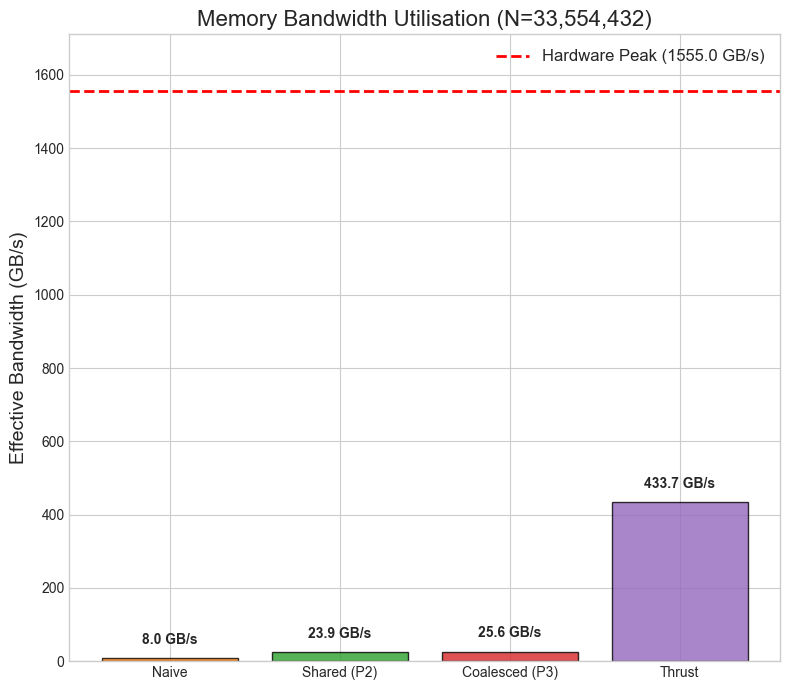

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))

labels     = ['Naive', 'Shared (P2)', 'Coalesced (P3)', 'Thrust']
bandwidths = [bw_naive, bw_p2, bw_p3, bw_thrust]
colors     = [COLORS['Naive'], COLORS['P2'], COLORS['P3'], COLORS['Thrust']]

bars = ax.bar(labels, bandwidths, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(PEAK_BANDWIDTH_GBPS, color='red', linestyle='--', linewidth=2,
           label=f'Hardware Peak ({PEAK_BANDWIDTH_GBPS} GB/s)')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + PEAK_BANDWIDTH_GBPS * 0.02,
            f'{yval:.1f} GB/s', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, PEAK_BANDWIDTH_GBPS * 1.1)
ax.set_ylabel('Effective Bandwidth (GB/s)', fontsize=14)
ax.set_title(f'Memory Bandwidth Utilisation (N={N_max:,})', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

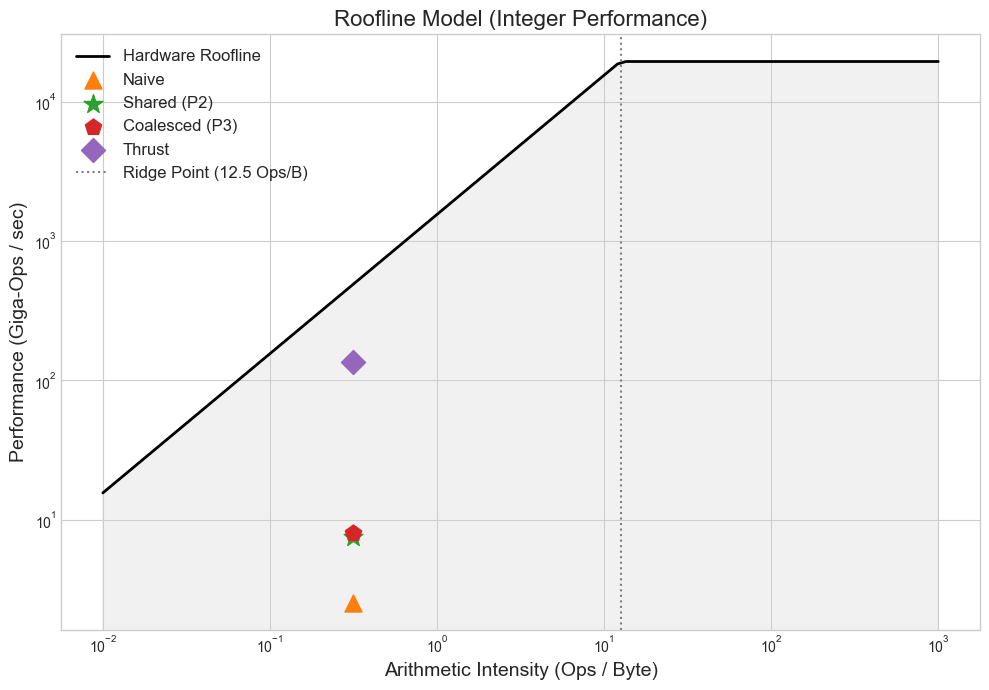

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

x_roof = np.logspace(-2, 3, 100)
y_roof = np.minimum(PEAK_COMPUTE_GOPS, x_roof * PEAK_BANDWIDTH_GBPS)

ax.plot(x_roof, y_roof, color='black', linewidth=2, label='Hardware Roofline')
ax.fill_between(x_roof, 0, y_roof, color='lightgray', alpha=0.3)

ax.scatter([ARITHMETIC_INTENSITY], [gops_naive],  color=COLORS['Naive'],  s=150, marker='^', zorder=5, label='Naive')
ax.scatter([ARITHMETIC_INTENSITY], [gops_p2],     color=COLORS['P2'],     s=200, marker='*', zorder=5, label='Shared (P2)')
ax.scatter([ARITHMETIC_INTENSITY], [gops_p3],     color=COLORS['P3'],     s=150, marker='p', zorder=5, label='Coalesced (P3)')
ax.scatter([ARITHMETIC_INTENSITY], [gops_thrust], color=COLORS['Thrust'], s=150, marker='D', zorder=5, label='Thrust')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Arithmetic Intensity (Ops / Byte)', fontsize=14)
ax.set_ylabel('Performance (Giga-Ops / sec)', fontsize=14)
ax.set_title('Roofline Model (Integer Performance)', fontsize=16)

ridge_point = PEAK_COMPUTE_GOPS / PEAK_BANDWIDTH_GBPS
ax.axvline(ridge_point, color='gray', linestyle=':', label=f'Ridge Point ({ridge_point:.1f} Ops/B)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

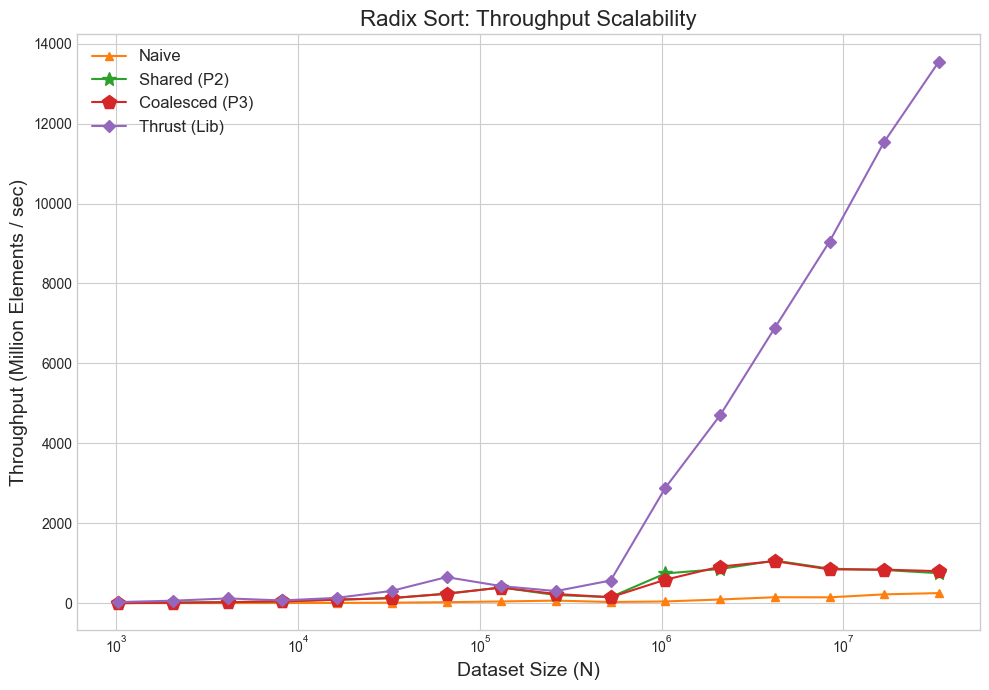

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df4['Size'], df4['Thru_Naive'],  marker='^',               label='Naive',           color=COLORS['Naive'])
ax.plot(df4['Size'], df4['Thru_P2'],     marker='*', markersize=10, label='Shared (P2)',    color=COLORS['P2'])
ax.plot(df4['Size'], df4['Thru_P3'],     marker='p', markersize=10, label='Coalesced (P3)', color=COLORS['P3'])
ax.plot(df4['Size'], df4['Thru_Thrust'], marker='D',               label='Thrust (Lib)',    color=COLORS['Thrust'])

ax.set_xscale('log')
ax.set_xlabel('Dataset Size (N)', fontsize=14)
ax.set_ylabel('Throughput (Million Elements / sec)', fontsize=14)
ax.set_title('Radix Sort: Throughput Scalability', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

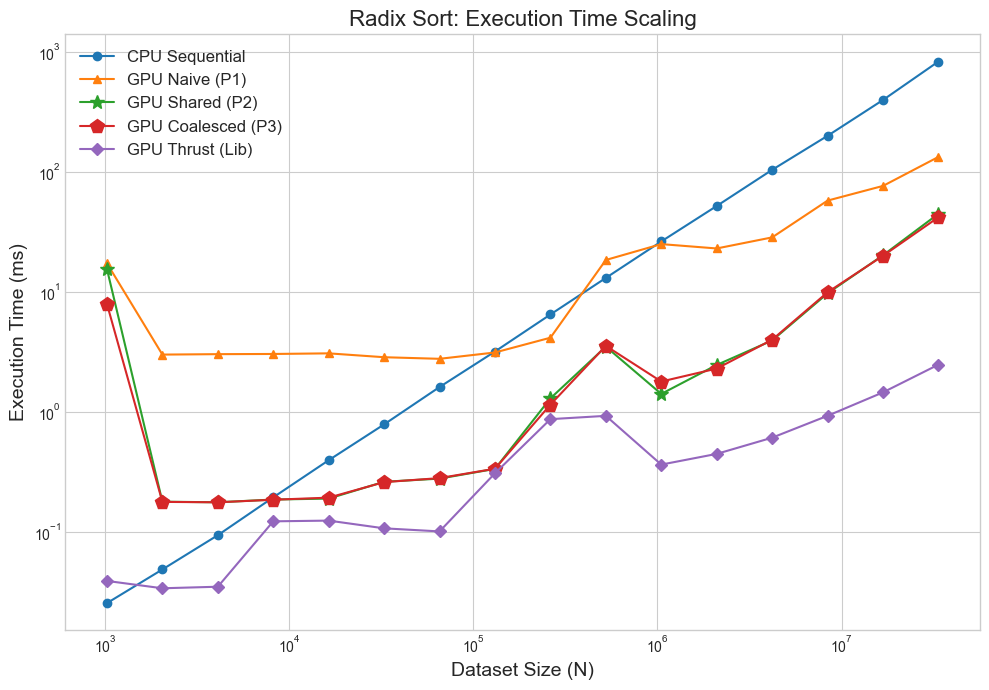

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df4['Size'], df4['CPU_ms'],        marker='o',               label='CPU Sequential',    color=COLORS['CPU'])
ax.plot(df4['Size'], df4['GPU_Naive_ms'],  marker='^',               label='GPU Naive (P1)',    color=COLORS['Naive'])
ax.plot(df4['Size'], df4['GPU_P2_Opt_ms'], marker='*', markersize=10, label='GPU Shared (P2)',   color=COLORS['P2'])
ax.plot(df4['Size'], df4['GPU_P3_Opt_ms'], marker='p', markersize=10, label='GPU Coalesced (P3)',color=COLORS['P3'])
ax.plot(df4['Size'], df4['GPU_Thrust_ms'], marker='D',               label='GPU Thrust (Lib)',  color=COLORS['Thrust'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dataset Size (N)', fontsize=14)
ax.set_ylabel('Execution Time (ms)', fontsize=14)
ax.set_title('Radix Sort: Execution Time Scaling', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

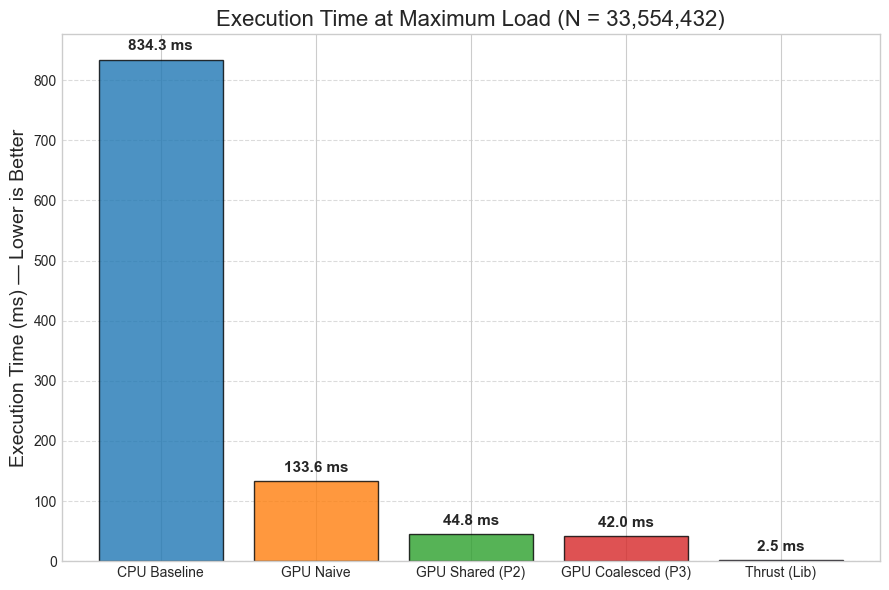

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

labels = ['CPU Baseline', 'GPU Naive', 'GPU Shared (P2)', 'GPU Coalesced (P3)', 'Thrust (Lib)']
times  = [row_max['CPU_ms'], row_max['GPU_Naive_ms'], row_max['GPU_P2_Opt_ms'], row_max['GPU_P3_Opt_ms'], row_max['GPU_Thrust_ms']]
colors = [COLORS['CPU'], COLORS['Naive'], COLORS['P2'], COLORS['P3'], COLORS['Thrust']]

bars = ax.bar(labels, times, color=colors, alpha=0.8, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 10,
            f'{yval:.1f} ms', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Execution Time (ms) — Lower is Better', fontsize=14)
ax.set_title(f'Execution Time at Maximum Load (N = {N_max:,})', fontsize=16)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Summary Dashboard

Three-panel overview combining speedup, bandwidth utilisation, and roofline positioning for a single at-a-glance comparison.

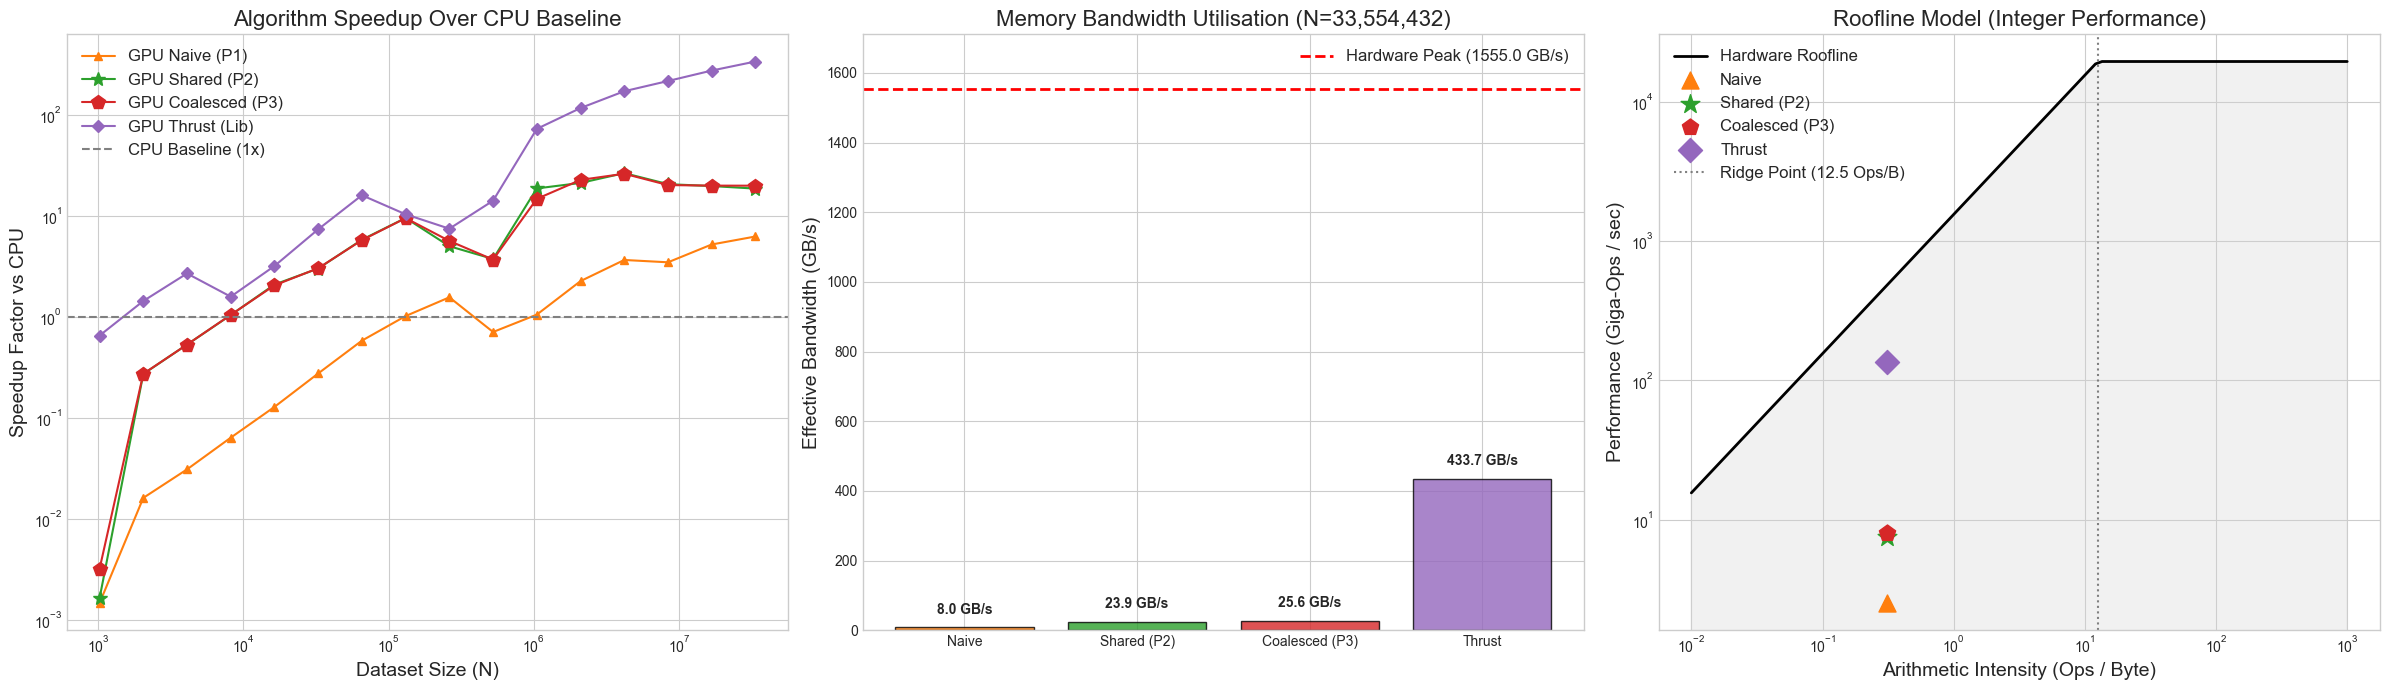

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

# Speedup
ax1.plot(df4['Size'], df4['Speedup_Naive'],  marker='^',               label='GPU Naive (P1)',    color=COLORS['Naive'])
ax1.plot(df4['Size'], df4['Speedup_P2'],     marker='*', markersize=10, label='GPU Shared (P2)',   color=COLORS['P2'])
ax1.plot(df4['Size'], df4['Speedup_P3'],     marker='p', markersize=10, label='GPU Coalesced (P3)',color=COLORS['P3'])
ax1.plot(df4['Size'], df4['Speedup_Thrust'], marker='D',               label='GPU Thrust (Lib)',  color=COLORS['Thrust'])
ax1.axhline(1, color='gray', linestyle='--', label='CPU Baseline (1x)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Dataset Size (N)', fontsize=14)
ax1.set_ylabel('Speedup Factor vs CPU', fontsize=14)
ax1.set_title('Algorithm Speedup Over CPU Baseline', fontsize=16)
ax1.legend(fontsize=12)

# Bandwidth
labels     = ['Naive', 'Shared (P2)', 'Coalesced (P3)', 'Thrust']
bandwidths = [bw_naive, bw_p2, bw_p3, bw_thrust]
bar_colors = [COLORS['Naive'], COLORS['P2'], COLORS['P3'], COLORS['Thrust']]

bars = ax2.bar(labels, bandwidths, color=bar_colors, alpha=0.8, edgecolor='black')
ax2.axhline(PEAK_BANDWIDTH_GBPS, color='red', linestyle='--', linewidth=2,
            label=f'Hardware Peak ({PEAK_BANDWIDTH_GBPS} GB/s)')
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, yval + PEAK_BANDWIDTH_GBPS * 0.02,
             f'{yval:.1f} GB/s', ha='center', va='bottom', fontweight='bold')
ax2.set_ylim(0, PEAK_BANDWIDTH_GBPS * 1.1)
ax2.set_ylabel('Effective Bandwidth (GB/s)', fontsize=14)
ax2.set_title(f'Memory Bandwidth Utilisation (N={N_max:,})', fontsize=16)
ax2.legend(fontsize=12)

# Roofline
x_roof = np.logspace(-2, 3, 100)
y_roof = np.minimum(PEAK_COMPUTE_GOPS, x_roof * PEAK_BANDWIDTH_GBPS)
ax3.plot(x_roof, y_roof, color='black', linewidth=2, label='Hardware Roofline')
ax3.fill_between(x_roof, 0, y_roof, color='lightgray', alpha=0.3)
ax3.scatter([ARITHMETIC_INTENSITY], [gops_naive],  color=COLORS['Naive'],  s=150, marker='^', zorder=5, label='Naive')
ax3.scatter([ARITHMETIC_INTENSITY], [gops_p2],     color=COLORS['P2'],     s=200, marker='*', zorder=5, label='Shared (P2)')
ax3.scatter([ARITHMETIC_INTENSITY], [gops_p3],     color=COLORS['P3'],     s=150, marker='p', zorder=5, label='Coalesced (P3)')
ax3.scatter([ARITHMETIC_INTENSITY], [gops_thrust], color=COLORS['Thrust'], s=150, marker='D', zorder=5, label='Thrust')
ridge_point = PEAK_COMPUTE_GOPS / PEAK_BANDWIDTH_GBPS
ax3.axvline(ridge_point, color='gray', linestyle=':', label=f'Ridge Point ({ridge_point:.1f} Ops/B)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('Arithmetic Intensity (Ops / Byte)', fontsize=14)
ax3.set_ylabel('Performance (Giga-Ops / sec)', fontsize=14)
ax3.set_title('Roofline Model (Integer Performance)', fontsize=16)
ax3.legend(fontsize=12)

plt.tight_layout()
plt.show()